# Simulating Geometric Brownian Motion

Geometric Brownian Motion (GBM) $S$ is defined by $S_0 > 0$ and the dynamics as defined in the following Stochastic Differential Equation (SDE):

$dS_t = {\mu}S_t dt + \sigma S_t dW_t$

Explicit Expression:

$S_t = S_0 \exp(\mu - \frac{\sigma^2}{2}t + \sigma W_t)$

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# Drift coefficient
mu = 0.1

# Number of steps
n = 100

# Time in years
T = 1

# number of simulations
M = 100

# Initial stock price
S0 = 100

# Volatility
sigma = 0.3

### Simulating GBM Paths

In [3]:
# Calc each time step
dt = T / n

# Simulation using numpy arrays
# We take the transpose of Wt (stochastic component) because we want the simulations for each time-step
St = np.exp(
    (mu - sigma**2/2)*dt
    + sigma*np.random.normal(0, np.sqrt(dt), size=(M,n)).T
)

# Include array of 1's
St = np.vstack([np.ones(M), St])

# Multiply through by S0 and return cumulative product of elements along a given simulation path
St = S0 * St.cumprod(axis=0)

### Consider time intervals in years

In [7]:
# Define time interval correctly
time = np.linspace(0,T,n+1)

# Require numpy array that is the same shape as St
tt = np.full(shape=(M,n+1), fill_value=time).T

### Plotting the Results

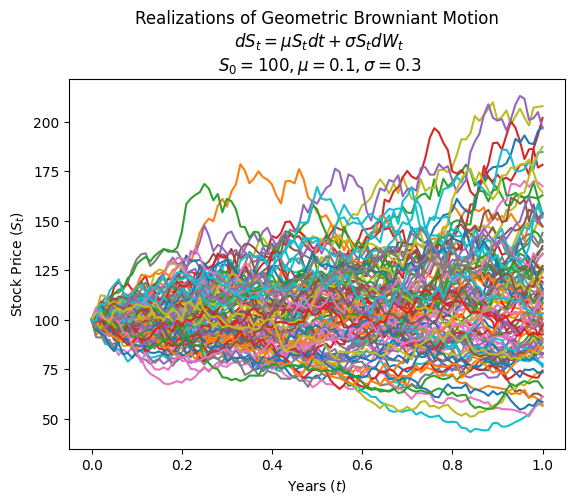

In [10]:
plt.plot(tt, St)
plt.xlabel('Years $(t)$')
plt.ylabel('Stock Price $(S_t)$')
plt.title(
    'Realizations of Geometric Browniant Motion\n $dS_t = \mu S_t dt + \sigma S_t dW_t$\n $S_0 = {0}, \mu = {1}, \sigma = {2}$'.format(S0, mu, sigma)
)
plt.show()